In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Stap 2: Data inlezen
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')
df = df.dropna()

print("Data geladen voor Clustering!")

Data geladen voor Clustering!


In [2]:
# --- INITIËLE RUN ---

# Stap 3: Features kiezen. Let op: Geen Target (y) bij clustering!
# We willen huizen groeperen op Oppervlakte, Bouwjaar en Buurt.
X_cluster = df[['Gr Liv Area', 'Year Built', 'Neighborhood']].copy()

# Stap 4: One-hot encoding voor categorische data (Neighborhood)
X_cluster_enc = pd.get_dummies(X_cluster, columns=['Neighborhood'], drop_first=True)

# Belangrijk: Scaling! K-Means berekent afstanden. We moeten alles op dezelfde schaal brengen.
scaler1 = StandardScaler()
X_cluster_scaled = scaler1.fit_transform(X_cluster_enc)

# Stap 5: Model initialiseren (3 clusters gekozen, n_init is een hyperparameter)
kmeans_init = KMeans(n_clusters=3, n_init=10, random_state=42)

# Model trainen en voorspellen in één stap
clusters_init = kmeans_init.fit_predict(X_cluster_scaled)

# Stap 6: Evalueren. We gebruiken de 'Silhouette Score' (tussen -1 en 1, hoe hoger hoe beter)
sil_score_init = silhouette_score(X_cluster_scaled, clusters_init)

print("--- Initiële Run ---")
print(f"Silhouette Score: {sil_score_init:.4f}")

--- Initiële Run ---
Silhouette Score: 0.1171


In [3]:
# --- EXPERIMENT 1 ---

# Stap 7: Experimenteren met meer features en 5 clusters
X_exp1 = df[['Gr Liv Area', 'Year Built', 'Neighborhood', 'Overall Qual', 'Garage']].copy()
X_exp1_enc = pd.get_dummies(X_exp1, columns=['Neighborhood', 'Garage'], drop_first=True)

scaler2 = StandardScaler()
X_exp1_scaled = scaler2.fit_transform(X_exp1_enc)

# Andere hyperparameters: 5 clusters, initiatie methode aangepast
kmeans_exp1 = KMeans(n_clusters=5, init='random', n_init=20, max_iter=500, random_state=42)
clusters_exp1 = kmeans_exp1.fit_predict(X_exp1_scaled)

sil_score_exp1 = silhouette_score(X_exp1_scaled, clusters_exp1)

print("--- Experiment 1 ---")
print(f"Silhouette Score: {sil_score_exp1:.4f}")

--- Experiment 1 ---
Silhouette Score: 0.1279


In [4]:
# --- EXPERIMENT 2 ---

# Veel categorieën (zoals Neighborhood) maken de berekening lastig voor K-Means (Curse of Dimensionality).
# We proberen nu minder categorieën ('House Style') en minder clusters (2).
X_exp2 = df[['Gr Liv Area', 'Overall Qual', 'House Style']].copy()
X_exp2_enc = pd.get_dummies(X_exp2, columns=['House Style'], drop_first=True)

scaler3 = StandardScaler()
X_exp2_scaled = scaler3.fit_transform(X_exp2_enc)

kmeans_exp2 = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters_exp2 = kmeans_exp2.fit_predict(X_exp2_scaled)

sil_score_exp2 = silhouette_score(X_exp2_scaled, clusters_exp2)

print("--- Experiment 2 ---")
print(f"Silhouette Score: {sil_score_exp2:.4f}")

--- Experiment 2 ---
Silhouette Score: 0.3813


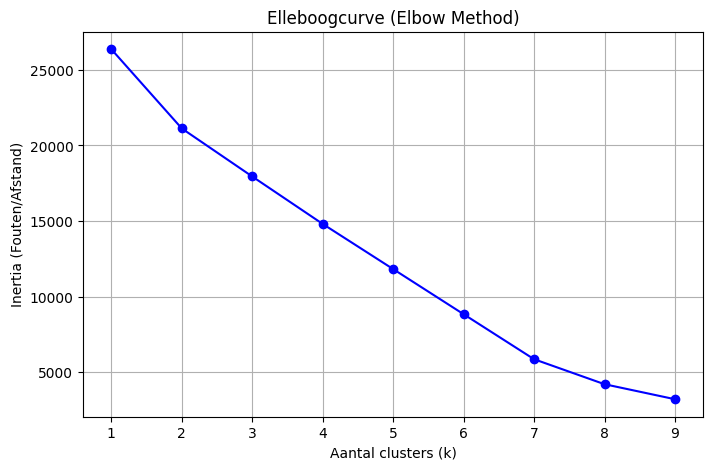

In [9]:
# --- EKSTRA: ELBOW (DIRSEK) METODU GÖRSELLEŞTİRME ---
import matplotlib.pyplot as plt

# K-Means'in hatalarını toplayacağımız boş bir liste
inertias = []
k_values = range(1, 10)

# 1'den 10'a kadar farklı küme sayılarını Experiment 2 verimizle deniyoruz
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_exp2_scaled)  # Experiment 2'deki doğru ölçeklenmiş veriyi kullanıyoruz!
    inertias.append(kmeans.inertia_)

# Grafiği çizdirme
plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o', color='b')
plt.xlabel('Aantal clusters (k)')
plt.ylabel('Inertia (Fouten/Afstand)')
plt.title('Elleboogcurve (Elbow Method)')
plt.grid(True)
plt.show()

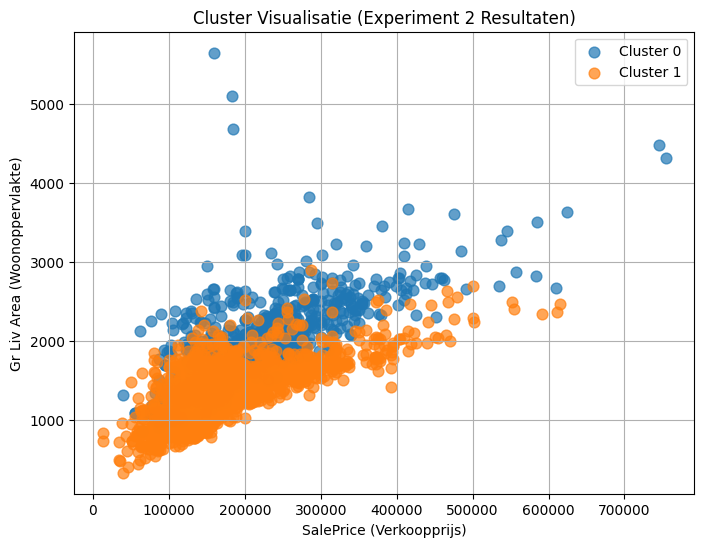

In [10]:
# --- EKSTRA: KÜMELERİ (CLUSTERS) GÖRSELLEŞTİRME ---

# Ana verimizin kopyasını alıp, Experiment 2'de bulduğumuz küme numaralarını (0 ve 1) ekliyoruz
df_visual = df.copy()
df_visual['Cluster'] = clusters_exp2 

# Grafiğin boyutu
plt.figure(figsize=(8, 6))

# Her bir kümeyi ayrı renkte çizdirmek için döngü
for cluster_id, group in df_visual.groupby('Cluster'):
    plt.scatter(
        group['SalePrice'], 
        group['Gr Liv Area'], 
        label=f'Cluster {cluster_id}', 
        alpha=0.7, 
        s=60
    )

plt.xlabel('SalePrice (Verkoopprijs)')
plt.ylabel('Gr Liv Area (Woonoppervlakte)')
plt.title('Cluster Visualisatie (Experiment 2 Resultaten)')
plt.legend()
plt.grid(True)
plt.show()